# What is a Conditional GAN?

A Conditional GAN is a type of GAN where we have control over what kind of data we want to generate. Both the generator and discriminator receive additional information (a "condition") about the data.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import urllib.request
import time
from functools import wraps
import glob
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, cohen_kappa_score, log_loss
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

# !pip install gensim
from gensim.utils import simple_preprocess

import builtins
zip = builtins.zip   # restore the real zip function

import warnings
warnings.filterwarnings('ignore')


In [48]:
class_labels = sorted([path.split('\\')[-1] for path in glob.glob(os.path.join('awa_data', 'test', '*'))])
lables_dict = {k:v for k, v in enumerate(class_labels) }
class_dict = {v: k for k, v in lables_dict.items()}
print(class_labels)
print(lables_dict)
print(class_dict)

VGG16_based_feature_path = 'VGG16_based_feature.csv'


# ========================================================
# NO NEED TO RUN -->
# ========================================================

# np.random.seed(42)
# n_samples = 5000
# n_features = 20
# n_classes = 5

# # Create synthetic dataset
# X = np.random.randn(n_samples, n_features)
# y = np.random.choice(range(n_classes), n_samples)

# # Add some class-specific patterns
# for class_id in range(n_classes):
#     mask = y == class_id
#     X[mask, :5] += class_id * 0.5

# df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(n_features)])
# df['label'] = y

# df.head()

# # df.to_csv('sample_data.csv', index=False)
# # print(f" Created sample_data.csv with {n_samples} samples")

['bear', 'blue_whale', 'bobcat', 'cow', 'dolphin', 'gorilla', 'killer_whale', 'lion', 'monkey', 'mouse', 'ox', 'rabbit', 'rhinoceros', 'siamese_cat', 'skunk', 'squirrel', 'tiger', 'walrus']
{0: 'bear', 1: 'blue_whale', 2: 'bobcat', 3: 'cow', 4: 'dolphin', 5: 'gorilla', 6: 'killer_whale', 7: 'lion', 8: 'monkey', 9: 'mouse', 10: 'ox', 11: 'rabbit', 12: 'rhinoceros', 13: 'siamese_cat', 14: 'skunk', 15: 'squirrel', 16: 'tiger', 17: 'walrus'}
{'bear': 0, 'blue_whale': 1, 'bobcat': 2, 'cow': 3, 'dolphin': 4, 'gorilla': 5, 'killer_whale': 6, 'lion': 7, 'monkey': 8, 'mouse': 9, 'ox': 10, 'rabbit': 11, 'rhinoceros': 12, 'siamese_cat': 13, 'skunk': 14, 'squirrel': 15, 'tiger': 16, 'walrus': 17}


# Basic Function's

In [3]:
def timer(func):
    """Simple decorator that prints execution time"""
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"{func.__name__} took {end - start:.4f} seconds")
        return result
    return wrapper

# VGG16 - Feature Extraction + Label Collection

In [4]:
# Feature Extractor
def build_feature_extractor():
    base_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    return base_model

# Create the feature extractor
feature_extractor = build_feature_extractor()
# feature_extractor.summary()

# variables - dataset path
train_data_path = os.path.join('awa_data', 'train') # /content/train
val_data_path = os.path.join('awa_data', 'test')
test_data_path = os.path.join('awa_data', 'test')

# Load and Preprocess Images
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = datagen.flow_from_directory(train_data_path,
                                         target_size = (224, 224),
                                         batch_size = 16,
                                         class_mode = 'categorical')
val_data = datagen.flow_from_directory(val_data_path,
                                       target_size = (224, 224),
                                       batch_size = 16,
                                       class_mode = 'categorical')
test_data = datagen.flow_from_directory(test_data_path,
                                        target_size = (224, 224),
                                        batch_size = 16,
                                        class_mode = 'categorical')

# X_train_features = []
# y_train_labels = []

# # Loop over train_data batches
# for images, labels in tqdm(train_data, desc="Processing images"):
#     features = feature_extractor.predict(images, verbose=0)
#     X_train_features.append(features)
#     y_train_labels.append(np.argmax(labels, axis=1))  # categorical class_mode

#     # break early if too large
#     if len(X_train_features) * train_data.batch_size > 10000:
#         break

# # Stack all batches into arrays
# X_train_features = np.vstack(X_train_features)
# y_train_labels = np.concatenate(y_train_labels)

# # create dataframe
# data = pd.DataFrame(X_train_features)
# data['lable'] = y_train_labels
# display(data.head())

# # save df
# data.to_csv(VGG16_based_feature_path, index=False)




Found 720 images belonging to 18 classes.
Found 144 images belonging to 18 classes.
Found 144 images belonging to 18 classes.


In [5]:
# VGG16_based_feature
VGG16_based_feature_path = 'VGG16_based_feature.csv' # VGG16_based_feature_path
VGG16_based_feature_df = pd.read_csv(VGG16_based_feature_path)
VGG16_based_feature_df.head()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,lable
0,0.000000,0.000000,2.229142,0.011475,7.670272,0.000000,1.390783,0.165571,0.000000,0.000000,...,0.315372,2.407517,0.104108,0.806510,0.006480,0.053511,0.005393,0.989186,0.012912,14
1,0.000000,0.000000,0.784312,1.682653,2.199253,0.626702,0.330303,0.209937,0.000000,0.019054,...,0.000000,0.995877,0.168801,0.000000,1.013197,0.000000,1.901440,1.583734,0.490907,1
2,0.228439,0.000000,8.382436,0.438487,3.759569,0.000000,0.310031,1.478327,0.000000,3.895598,...,0.223582,0.772686,4.483770,9.838275,0.000000,0.000000,0.000000,1.146780,1.052495,2
3,0.000000,2.658575,6.285603,0.425270,1.032921,0.546718,0.000000,7.580545,4.449940,0.828965,...,0.253676,0.170907,2.360377,0.427400,0.621986,0.172378,0.779462,4.182479,0.364286,5
4,0.000000,0.000000,1.276470,0.315434,0.827329,9.324952,0.309158,0.310180,5.938623,0.259464,...,0.000000,1.227598,0.000000,0.000000,0.293086,0.000000,1.096719,0.081517,0.819864,14


In [6]:
VGG16_based_feature_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,lable
count,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,...,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000,10016.000000
mean,2.228957,0.939323,5.255194,0.886049,5.767695,1.778641,0.552225,3.358322,2.571520,1.638192,...,0.933011,2.727392,4.408932,3.351510,0.675178,0.704263,2.002192,1.694560,2.664474,8.503494
std,3.259398,1.855742,6.011461,1.463743,7.239140,2.584128,1.022466,7.711435,4.772866,2.250151,...,1.338762,3.572858,5.668812,4.265356,1.210078,1.504018,3.289500,2.106486,5.518863,5.185735
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.070475,0.000000,0.676086,0.000000,1.044831,0.133794,0.000000,0.111700,0.001958,0.187196,...,0.038309,0.529954,0.352232,0.275313,0.000000,0.000000,0.045095,0.270296,0.089087,4.000000
50%,1.020250,0.183350,3.145335,0.242195,3.348945,0.787051,0.114532,1.122302,0.689187,0.843035,...,0.423108,1.536614,2.215580,1.628472,0.203707,0.053511,0.725453,1.027228,0.778061,9.000000
75%,3.052786,1.140559,7.754815,1.185013,7.423755,2.212881,0.641095,3.790316,2.975481,2.112495,...,1.250136,3.588490,6.516430,5.090719,0.833914,0.728472,2.616890,2.308505,2.734771,13.000000
max,23.023073,24.327232,37.919590,11.539531,59.185074,19.502130,8.707838,118.540620,45.050808,18.003525,...,9.970460,30.423779,38.337740,24.812460,13.898226,12.189206,39.519016,17.581250,58.814890,17.000000


In [7]:
# 

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, cohen_kappa_score, log_loss
import joblib
import pickle

# Load your CSV file
df = pd.read_csv(VGG16_based_feature_path)  # Replace with your actual file path

# Separate features and label
X = df.iloc[:, :-1]  # First 512 columns are features
y = df.iloc[:, -1]   # Last column is the label

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and fit MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler to a pickle file
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
# Alternative using joblib (often more efficient for large arrays)
# joblib.dump(scaler, 'scaler_joblib.pkl')

print("Scaler saved to 'scaler.pkl' and 'scaler_joblib.pkl'")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

# Train a Machine Learning model (Random Forest as example)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

# For loss (log loss/cross-entropy loss)
# Note: log_loss works with probabilities
loss = log_loss(y_test, y_pred_proba)

# Classification report
class_report = classification_report(y_test, y_pred)

# AUC-ROC (for multi-class, use 'macro' or 'weighted' average)
# Check if binary or multi-class classification
n_classes = len(np.unique(y))
if n_classes == 2:
    aucroc = roc_auc_score(y_test, y_pred_proba[:, 1])
else:
    aucroc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

# Cohen's Kappa Score
kappa = cohen_kappa_score(y_test, y_pred)

# Print evaluation metrics
print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Loss (Log Loss): {loss:.4f}")
print(f"AUC-ROC Score: {aucroc:.4f}")
print(f"Cohen's Kappa Score: {kappa:.4f}")
print("\nClassification Report:")
print(class_report)
print("="*50)

# Save the model to a pickle file
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Also save using joblib (recommended for scikit-learn models)
joblib.dump(model, 'model_joblib.pkl')

print(f"\nModel saved to 'model.pkl' and 'model_joblib.pkl'")

# Optional: Save metrics to a text file
with open('evaluation_metrics.txt', 'w') as f:
    f.write("MODEL EVALUATION METRICS\n")
    f.write("="*50 + "\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Loss (Log Loss): {loss:.4f}\n")
    f.write(f"AUC-ROC Score: {aucroc:.4f}\n")
    f.write(f"Cohen's Kappa Score: {kappa:.4f}\n")
    f.write("\nClassification Report:\n")
    f.write(class_report)
    
print("Evaluation metrics saved to 'evaluation_metrics.txt'")

Scaler saved to 'scaler.pkl' and 'scaler_joblib.pkl'
Training set shape: (8012, 512)
Test set shape: (2004, 512)

MODEL EVALUATION METRICS
Accuracy: 1.0000
Loss (Log Loss): 0.0000
AUC-ROC Score: 1.0000
Cohen's Kappa Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       111
           1       1.00      1.00      1.00       111
           2       1.00      1.00      1.00       111
           3       1.00      1.00      1.00       111
           4       1.00      1.00      1.00       112
           5       1.00      1.00      1.00       111
           6       1.00      1.00      1.00       111
           7       1.00      1.00      1.00       112
           8       1.00      1.00      1.00       111
           9       1.00      1.00      1.00       112
          10       1.00      1.00      1.00       112
          11       1.00      1.00      1.00       112
          12       1.00      1.00      1.00

# To load and use the saved model and scaler

In [9]:
import joblib
import pickle
import pandas as pd

# Load the model
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Or using joblib
loaded_model = joblib.load('model_joblib.pkl')

# Load the scaler
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Or using joblib
loaded_scaler = joblib.load('scaler_joblib.pkl')

# To make predictions on new data
new_data = X_test # pd.read_csv('new_data.csv')  # 512 features
new_data_scaled = loaded_scaler.transform(new_data)
predictions = loaded_model.predict(new_data_scaled)
predictions

array([ 5, 16,  8, ..., 15, 13, 10], dtype=int64)

 INFOGAN + CONDITIONAL GAN

 Step 2: Preparing data...
 Data prepared:
   Training samples: 8012
   Test samples: 2004
   Features: 512
   Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
   Classes count: 18

 Step 3: Creating InfoGAN + Conditional GAN...

 Step 4: Training...
 Training InfoGAN + Conditional GAN...
   Latent dim: 50
   Code dim: 10
   Number of classes: 18
   Data dim: 512
Epoch 10/100 | D: 1.1516 | G: 1.0036 | Q: 3.0678
Epoch 20/100 | D: 1.0772 | G: 1.2278 | Q: 3.0032
Epoch 30/100 | D: 1.1279 | G: 1.0809 | Q: 3.0249
Epoch 40/100 | D: 1.0533 | G: 1.2119 | Q: 3.0813
Epoch 50/100 | D: 0.9501 | G: 1.3874 | Q: 3.1491
Epoch 60/100 | D: 0.8660 | G: 1.5726 | Q: 3.1616
Epoch 70/100 | D: 0.8126 | G: 1.7152 | Q: 3.2061
Epoch 80/100 | D: 0.7736 | G: 1.8975 | Q: 3.2062
Epoch 90/100 | D: 0.7062 | G: 2.0249 | Q: 3.2333
Epoch 100/100 | D: 0.6242 | G: 2.3006 | Q: 3.2676

 Step 5: Plotting training history...


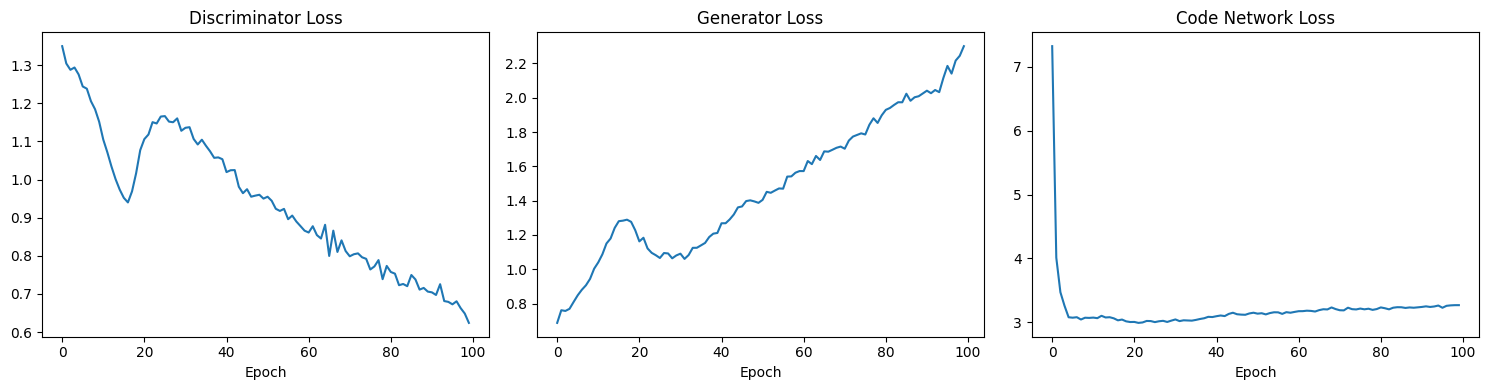


 Step 6: Generating samples...

Class '0' generated samples (first 5 features):
[[ 0.95892376 -0.5369868   0.93643945 -0.48700306  0.90253466]
 [ 0.70973337 -0.570662    0.9822652  -0.48709077  0.7430466 ]
 [ 0.8924401  -0.7217785   0.98163456 -0.7199176   0.9423453 ]
 [ 0.8044538  -0.06083647  0.9289863  -0.56605846  0.22821502]
 [ 0.8298939  -0.61927027  0.98206395 -0.31620458  0.91882396]]


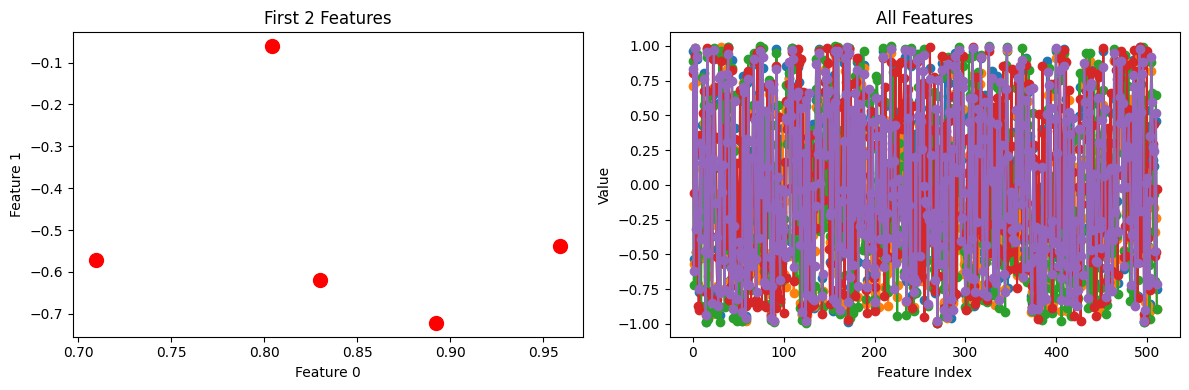


Class '1' generated samples (first 5 features):
[[-0.47300968  0.15097986 -0.5987128  -0.32798812 -0.7217539 ]
 [-0.4833651   0.57824844 -0.6428524  -0.2791842  -0.7460135 ]
 [ 0.17647481 -0.28968748 -0.35713002  0.06956709 -0.736319  ]
 [-0.3982715   0.40652683 -0.4012234  -0.21246417 -0.6236179 ]
 [-0.51189876  0.60656893 -0.77320665 -0.27546656 -0.7579065 ]]


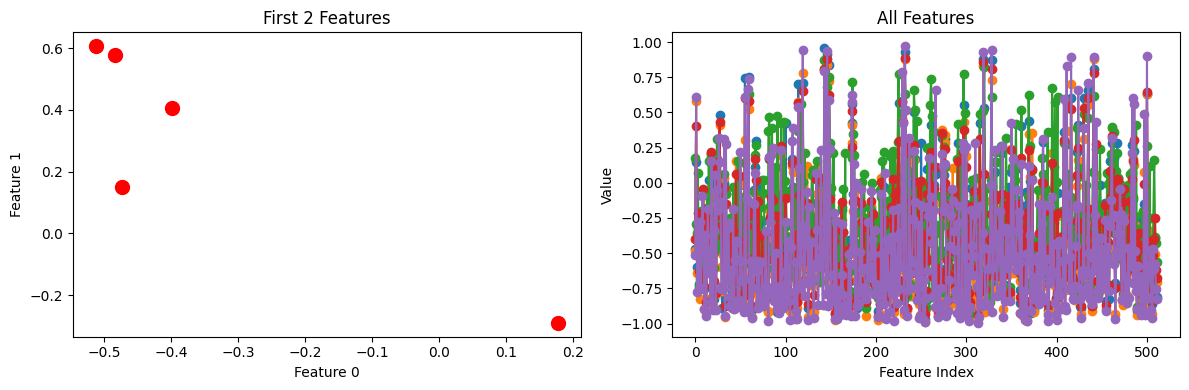


Class '2' generated samples (first 5 features):
[[-0.37453967 -0.5829305  -0.76081735 -0.40915242 -0.12110819]
 [-0.30637893 -0.45444515 -0.7935128   0.00630806  0.21096161]
 [-0.27491465 -0.5721045  -0.3279918  -0.61929125 -0.7041223 ]
 [-0.5159785  -0.09202994 -0.61752754 -0.6238456  -0.17719655]
 [-0.14795871 -0.49620044 -0.83751744 -0.79151565 -0.17959583]]


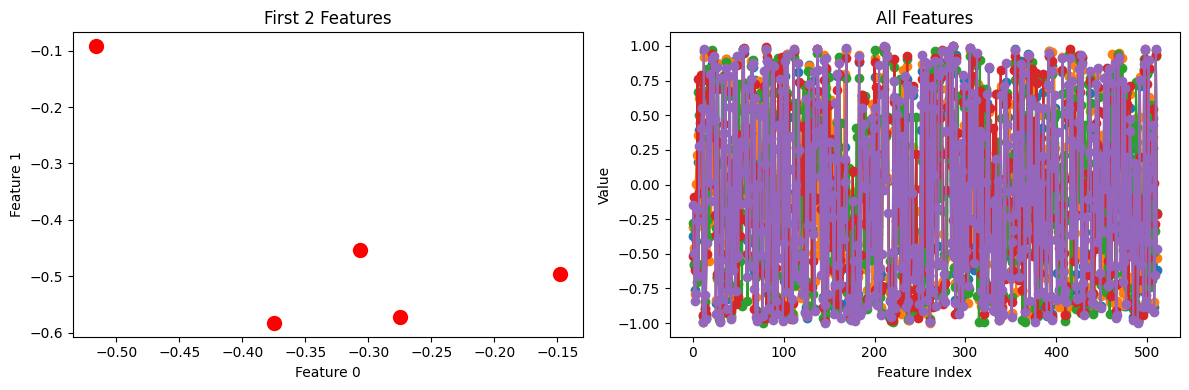


 Step 7: Exploring latent codes...
Varying code dimension 0 for class '0':
  code=-2.00 -> sample[0][:5] = [ 0.736229   -0.32489955  0.9844724  -0.5868057   0.41438174]
  code=-1.00 -> sample[0][:5] = [ 0.8840807  -0.76485795  0.94105756 -0.5996626   0.79722416]
  code=0.00 -> sample[0][:5] = [ 0.7505963  -0.8488875   0.9837606  -0.8569609   0.98119646]
  code=1.00 -> sample[0][:5] = [ 0.8556519 -0.8109376  0.973766  -0.512306   0.9099581]
  code=2.00 -> sample[0][:5] = [ 0.82703483 -0.79387987  0.95532274  0.4140765   0.5018659 ]

 Step 8: Interpolating between codes...
Interpolated 5 samples

 Step 9: Saving models...
 Models saved to infogan_conditional_model_*.h5

 Step 10: Comparing with real test data...
Real test sample (class 5):
  First 5 features: [-0.20462913 -0.31151837 -0.25851221  0.90522395 -0.50770984]
Generated sample for same class:
  First 5 features: [-0.8617546  -0.1615611  -0.01186385 -0.9992857  -0.9966013 ]

 Training complete!
model : <__main__.InfoConditional

In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ============================================
# PART 1: BUILD THE MODELS
# ============================================

class InfoConditionalGAN:
    """
    Combined InfoGAN + Conditional GAN
    """
    def __init__(self, latent_dim=50, code_dim=10, num_classes=10, data_dim=20):
        self.latent_dim = latent_dim    # Random noise dimension
        self.code_dim = code_dim        # Latent code dimension (InfoGAN)
        self.num_classes = num_classes  # Number of classes (Conditional GAN)
        self.data_dim = data_dim        # Output data dimension
        
        # Build models
        self.generator = self._build_generator()
        self.discriminator = self._build_discriminator()
        self.code_network = self._build_code_network()
        
        # Optimizers
        self.g_optimizer = tf.keras.optimizers.Adam(0.0002, 0.5)
        self.d_optimizer = tf.keras.optimizers.Adam(0.0002, 0.5)
        self.q_optimizer = tf.keras.optimizers.Adam(0.0002, 0.5)
        
        # Loss functions
        self.bce_loss = tf.keras.losses.BinaryCrossentropy()
        self.mse_loss = tf.keras.losses.MeanSquaredError()
        
        # History
        self.history = {'d_loss': [], 'g_loss': [], 'q_loss': []}
    
    def _build_generator(self):
        """
        Generator takes: noise + class label + latent code
        """
        # Input 1: Random noise
        noise_input = layers.Input(shape=(self.latent_dim,), name='noise')
        
        # Input 2: Class label (one-hot)
        label_input = layers.Input(shape=(self.num_classes,), name='class_label')
        
        # Input 3: Latent code (InfoGAN)
        code_input = layers.Input(shape=(self.code_dim,), name='latent_code')
        
        # Combine all inputs
        combined = layers.Concatenate()([noise_input, label_input, code_input])
        
        # Hidden layers
        x = layers.Dense(256)(combined)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
        
        x = layers.Dense(512)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
        
        x = layers.Dense(256)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
        
        # Output
        output = layers.Dense(self.data_dim, activation='tanh')(x)
        
        model = Model([noise_input, label_input, code_input], output, name='Generator')
        return model
    
    def _build_discriminator(self):
        """
        Discriminator takes: data + class label
        """
        # Input 1: Real/fake data
        data_input = layers.Input(shape=(self.data_dim,), name='data')
        
        # Input 2: Class label (one-hot)
        label_input = layers.Input(shape=(self.num_classes,), name='class_label')
        
        # Combine
        combined = layers.Concatenate()([data_input, label_input])
        
        # Hidden layers
        x = layers.Dense(256)(combined)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)
        
        x = layers.Dense(128)(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)
        
        x = layers.Dense(64)(x)
        x = layers.LeakyReLU(0.2)(x)
        
        # Output: real/fake probability
        output = layers.Dense(1, activation='sigmoid')(x)
        
        model = Model([data_input, label_input], output, name='Discriminator')
        return model
    
    def _build_code_network(self):
        """
        Code network (Q) predicts latent code from data (InfoGAN)
        """
        # Input: data
        data_input = layers.Input(shape=(self.data_dim,), name='data')
        
        # Hidden layers
        x = layers.Dense(128)(data_input)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Dense(64)(x)
        x = layers.LeakyReLU(0.2)(x)
        
        # Output: predicted latent code
        code_output = layers.Dense(self.code_dim, activation='linear')(x)
        
        model = Model(data_input, code_output, name='CodeNetwork')
        return model
    
    # ============================================
    # PART 2: TRAINING STEP
    # ============================================
    
    @tf.function
    def train_step(self, real_data, real_labels):
        """
        Single training step
        """
        batch_size = tf.shape(real_data)[0]
        
        # Create one-hot labels
        labels_one_hot = tf.one_hot(real_labels, self.num_classes)
        
        # Generate random noise and latent codes
        noise = tf.random.normal([batch_size, self.latent_dim])
        latent_codes = tf.random.uniform([batch_size, self.code_dim], -1, 1)
        
        # ===== Train Discriminator =====
        with tf.GradientTape() as d_tape:
            # Generate fake data
            fake_data = self.generator([noise, labels_one_hot, latent_codes], training=True)
            
            # Discriminator predictions
            real_output = self.discriminator([real_data, labels_one_hot], training=True)
            fake_output = self.discriminator([fake_data, labels_one_hot], training=True)
            
            # Losses
            d_real_loss = self.bce_loss(tf.ones_like(real_output), real_output)
            d_fake_loss = self.bce_loss(tf.zeros_like(fake_output), fake_output)
            d_loss = d_real_loss + d_fake_loss
        
        # Update discriminator
        d_gradients = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(d_gradients, self.discriminator.trainable_variables))
        
        # ===== Train Generator + Code Network =====
        with tf.GradientTape() as g_tape, tf.GradientTape() as q_tape:
            # Generate new fake data
            noise = tf.random.normal([batch_size, self.latent_dim])
            latent_codes = tf.random.uniform([batch_size, self.code_dim], -1, 1)
            fake_data = self.generator([noise, labels_one_hot, latent_codes], training=True)
            
            # Discriminator output on fake data
            fake_output = self.discriminator([fake_data, labels_one_hot], training=True)
            
            # Generator loss (want discriminator to think fake is real)
            g_loss = self.bce_loss(tf.ones_like(fake_output), fake_output)
            
            # Code network prediction and loss (InfoGAN part)
            predicted_codes = self.code_network(fake_data, training=True)
            q_loss = self.mse_loss(latent_codes, predicted_codes) * 10  # Scale factor
        
        # Update generator
        g_gradients = g_tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(g_gradients, self.generator.trainable_variables))
        
        # Update code network
        q_gradients = q_tape.gradient(q_loss, self.code_network.trainable_variables)
        self.q_optimizer.apply_gradients(zip(q_gradients, self.code_network.trainable_variables))
        
        return d_loss, g_loss, q_loss
    
    # ============================================
    # PART 3: TRAINING LOOP
    # ============================================
    
    def train(self, data, labels, epochs=100, batch_size=32):
        """
        Train the model
        """
        dataset = tf.data.Dataset.from_tensor_slices((data, labels))
        dataset = dataset.shuffle(len(data)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
        
        print(" Training InfoGAN + Conditional GAN...")
        print(f"   Latent dim: {self.latent_dim}")
        print(f"   Code dim: {self.code_dim}")
        print(f"   Number of classes: {self.num_classes}")
        print(f"   Data dim: {self.data_dim}")
        
        for epoch in range(epochs):
            epoch_d_loss = []
            epoch_g_loss = []
            epoch_q_loss = []
            
            for batch_data, batch_labels in dataset:
                d_loss, g_loss, q_loss = self.train_step(batch_data, batch_labels)
                epoch_d_loss.append(d_loss.numpy())
                epoch_g_loss.append(g_loss.numpy())
                epoch_q_loss.append(q_loss.numpy())
            
            # Store averages
            self.history['d_loss'].append(np.mean(epoch_d_loss))
            self.history['g_loss'].append(np.mean(epoch_g_loss))
            self.history['q_loss'].append(np.mean(epoch_q_loss))
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} | "
                      f"D: {self.history['d_loss'][-1]:.4f} | "
                      f"G: {self.history['g_loss'][-1]:.4f} | "
                      f"Q: {self.history['q_loss'][-1]:.4f}")
        
        return self
    
    # ============================================
    # PART 4: GENERATION FUNCTIONS
    # ============================================
    
    def generate_for_class(self, class_label, n_samples=10, fixed_code=None):
        """
        Generate samples for a specific class
        """
        # Create one-hot label
        label_one_hot = tf.one_hot([class_label] * n_samples, self.num_classes)
        
        # Generate noise
        noise = tf.random.normal([n_samples, self.latent_dim])
        
        # Handle latent code
        if fixed_code is None:
            latent_codes = tf.random.uniform([n_samples, self.code_dim], -1, 1)
        else:
            latent_codes = tf.tile(fixed_code[None, :], [n_samples, 1])
        
        # Generate
        samples = self.generator([noise, label_one_hot, latent_codes], training=False)
        
        return samples.numpy()
    
    def generate_with_code(self, class_label, latent_code, n_samples=10):
        """
        Generate samples with specific latent code (style)
        """
        return self.generate_for_class(class_label, n_samples, latent_code)
    
    def interpolate_codes(self, class_label, code1, code2, n_steps=10):
        """
        Interpolate between two latent codes
        """
        alphas = np.linspace(0, 1, n_steps)
        samples = []
        
        for alpha in alphas:
            interp_code = (1 - alpha) * code1 + alpha * code2
            sample = self.generate_for_class(class_label, 1, interp_code)
            samples.append(sample[0])
        
        return np.array(samples)
    
    def explore_code_dimension(self, class_label, code_idx, range_values=(-2, 2), n_steps=10):
        """
        Explore how changing one code dimension affects generation
        """
        # Base code (zeros)
        base_code = np.zeros(self.code_dim)
        
        values = np.linspace(range_values[0], range_values[1], n_steps)
        samples = []
        
        for val in values:
            code = base_code.copy()
            code[code_idx] = val
            sample = self.generate_for_class(class_label, 1, code)
            samples.append(sample[0])
        
        return np.array(samples), values
    
    # ============================================
    # PART 5: EVALUATION
    # ============================================
    
    def plot_history(self):
        """Plot training history"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        axes[0].plot(self.history['d_loss'])
        axes[0].set_title('Discriminator Loss')
        axes[0].set_xlabel('Epoch')
        
        axes[1].plot(self.history['g_loss'])
        axes[1].set_title('Generator Loss')
        axes[1].set_xlabel('Epoch')
        
        axes[2].plot(self.history['q_loss'])
        axes[2].set_title('Code Network Loss')
        axes[2].set_xlabel('Epoch')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_generated_samples(self, samples, class_names=None, n_show=5):
        """Visualize generated samples"""
        if samples.shape[1] > 2:
            # If high-dimensional, show first 2 features
            plt.figure(figsize=(12, 4))
            
            plt.subplot(1, 2, 1)
            plt.scatter(samples[:n_show, 0], samples[:n_show, 1], c='red', s=100)
            plt.title('First 2 Features')
            plt.xlabel('Feature 0')
            plt.ylabel('Feature 1')
            
            plt.subplot(1, 2, 2)
            plt.plot(samples[:n_show].T, 'o-')
            plt.title('All Features')
            plt.xlabel('Feature Index')
            plt.ylabel('Value')
        else:
            plt.figure(figsize=(10, 4))
            plt.plot(samples[:n_show].T, 'o-')
            plt.title('Generated Samples')
            plt.xlabel('Feature Index')
            plt.ylabel('Value')
        
        plt.tight_layout()
        plt.show()
    
    def save_models(self, path):
        """Save all models"""
        self.generator.save(f"{path}_generator.h5")
        self.discriminator.save(f"{path}_discriminator.h5")
        self.code_network.save(f"{path}_code_network.h5")
        print(f" Models saved to {path}_*.h5")

# ============================================
# PART 6: DATA PREPARATION
# ============================================

def prepare_data(csv_file, label_column, test_size=0.2):
    """
    Load and prepare data for training
    """
    # Load data
    df = pd.read_csv(csv_file)
    
    # Separate features and labels
    feature_columns = [col for col in df.columns if col != label_column]
    X = df[feature_columns].values
    y = df[label_column].values
    
    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    
    # Normalize features to [-1, 1]
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X)
    X_norm = np.clip(X_norm, -1, 1)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_norm, y_encoded, test_size=test_size, random_state=42, stratify=y_encoded
    )
    
    print(f" Data prepared:")
    print(f"   Training samples: {X_train.shape[0]}")
    print(f"   Test samples: {X_test.shape[0]}")
    print(f"   Features: {X_train.shape[1]}")
    print(f"   Classes: {le.classes_}")
    print(f"   Classes count: {len(le.classes_)}")
    
    return X_train, X_test, y_train, y_test, scaler, le, feature_columns

# ============================================
# PART 7: MAIN PIPELINE
# ============================================

def main(csv_file):
    """
    Complete training pipeline
    """
    print("="*60)
    print(" INFOGAN + CONDITIONAL GAN")
    print("="*60)
    
#     # Step 1: Create sample data (replace with your CSV)
#     print("\n Step 1: Creating sample data...")
#     np.random.seed(42)
#     n_samples = 5000
#     n_features = 20
#     n_classes = 5
    
#     # Create synthetic dataset
#     X = np.random.randn(n_samples, n_features)
#     y = np.random.choice(range(n_classes), n_samples)
    
#     # Add some class-specific patterns
#     for class_id in range(n_classes):
#         mask = y == class_id
#         X[mask, :5] += class_id * 0.5
    
#     df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(n_features)])
#     df['label'] = y
#     df.to_csv('sample_data.csv', index=False)
#     print(f" Created sample_data.csv with {n_samples} samples")
    
    # Load daset
    # Step 2: Prepare data
    print("\n Step 2: Preparing data...")
    X_train, X_test, y_train, y_test, scaler, label_encoder, feature_names = prepare_data(csv_file, 'lable')
    
    # Step 3: Create and train model
    print("\n Step 3: Creating InfoGAN + Conditional GAN...")
    model = InfoConditionalGAN(
        latent_dim=50,      # Random noise
        code_dim=10,        # Latent code (InfoGAN)
        num_classes=len(label_encoder.classes_),
        data_dim=X_train.shape[1]
    )
    
    # Step 4: Train
    print("\n Step 4: Training...")
    model.train(X_train, y_train, epochs=100, batch_size=64)
    
    # Step 5: Plot training history
    print("\n Step 5: Plotting training history...")
    model.plot_history()
    
    # Step 6: Generate samples for each class
    print("\n Step 6: Generating samples...")
    class_names = label_encoder.classes_
    
    for class_id in range(min(3, len(class_names))):
        samples = model.generate_for_class(class_id, n_samples=5)
        print(f"\nClass '{class_names[class_id]}' generated samples (first 5 features):")
        print(samples[:, :5])
        
        # Visualize
        model.visualize_generated_samples(samples, class_names)
    
    # Step 7: Explore latent codes
    print("\n Step 7: Exploring latent codes...")
    class_id = 0
    code_idx = 0
    
    samples, values = model.explore_code_dimension(
        class_id, code_idx, range_values=(-2, 2), n_steps=5
    )
    
    print(f"Varying code dimension {code_idx} for class '{class_names[class_id]}':")
    for i, val in enumerate(values):
        print(f"  code={val:.2f} -> sample[0][:5] = {samples[i, :5]}")
    
    # Step 8: Interpolate between codes
    print("\n Step 8: Interpolating between codes...")
    code1 = np.random.uniform(-1, 1, model.code_dim)
    code2 = np.random.uniform(-1, 1, model.code_dim)
    
    interpolated = model.interpolate_codes(class_id, code1, code2, n_steps=5)
    print(f"Interpolated {len(interpolated)} samples")
    
    # Step 9: Save models
    print("\n Step 9: Saving models...")
    model.save_models('infogan_conditional_model')
    
    # Step 10: Compare with test data
    print("\n Step 10: Comparing with real test data...")
    test_sample = X_test[0]
    test_label = y_test[0]
    
    print(f"Real test sample (class {class_names[test_label]}):")
    print(f"  First 5 features: {test_sample[:5]}")
    
    # Generate similar sample
    generated = model.generate_for_class(test_label, n_samples=1)[0]
    print(f"Generated sample for same class:")
    print(f"  First 5 features: {generated[:5]}")
    
    print("\n Training complete!")
    
    return model, scaler, label_encoder

# ============================================
# PART 8: REAL-TIME USAGE
# ============================================

class RealTimeGenerator:
    """
    Easy-to-use class for real-time generation
    """
    def __init__(self, model_path='infogan_conditional_model', scaler=None, label_encoder=None):
        # Load models
        self.generator = tf.keras.models.load_model(f"{model_path}_generator.h5")
        self.code_network = tf.keras.models.load_model(f"{model_path}_code_network.h5")
        
        self.scaler = scaler
        self.label_encoder = label_encoder
        
        # Get dimensions from model
        self.latent_dim = 50  # You might want to save these during training
        self.code_dim = 10
        self.num_classes = len(label_encoder.classes_) if label_encoder else 10
        
        print(" RealTimeGenerator ready!")
    
    def generate(self, class_name, n_samples=1, style=None, noise=None):
        """
        Generate samples for a specific class
        """
        # Convert class name to index
        if self.label_encoder:
            class_idx = self.label_encoder.transform([class_name])[0]
        else:
            class_idx = int(class_name)
        
        # Create one-hot
        label_one_hot = tf.one_hot([class_idx] * n_samples, self.num_classes)
        
        # Generate noise
        noise = tf.random.normal([n_samples, self.latent_dim])
        
        # Handle style/code
        if style is None:
            latent_codes = tf.random.uniform([n_samples, self.code_dim], -1, 1)
        else:
            latent_codes = tf.tile(style[None, :], [n_samples, 1])
        
        # Generate
        samples = self.generator([noise, label_one_hot, latent_codes], training=False)
        samples = samples.numpy()
        
        # Inverse transform if scaler provided
        if self.scaler:
            samples = self.scaler.inverse_transform(samples)
        
        return samples
    
    def generate_variations(self, class_name, n_variations=5, noise=None):
        """Generate multiple variations of the same class"""
        return self.generate(class_name, n_variations, noise=noise)
    
    def get_style_from_real(self, real_sample):
        """Extract style code from a real sample"""
        if self.scaler:
            real_sample = self.scaler.transform([real_sample])
        
        style = self.code_network(real_sample, training=False)
        return style.numpy()[0]

# ============================================
# PART 9: EXAMPLE USAGE
# ============================================

if __name__ == "__main__":
    # Train the model
    model, scaler, label_encoder = main(VGG16_based_feature_path)
    print(f"model : {model}, \nscaler : {scaler}, \nlabel_encoder : {label_encoder} ")
    
    # save model
    joblib.dump(scaler, 'RealTimeGenerator_scaler_joblib.pkl')
    joblib.dump(label_encoder, 'RealTimeGenerator_label_encoder_joblib.pkl')
    # loaded_model = joblib.load('model_joblib.pkl')

    # Real-time usage example
    print("\n" + "="*60)
    print(" REAL-TIME USAGE EXAMPLE")
    print("="*60)
    
    # Initialize real-time generator
    rt_gen = RealTimeGenerator(
        'infogan_conditional_model',
        scaler,
        label_encoder
    )
    
    # Generate samples for specific class
    class_name = label_encoder.classes_[0]
    print(f"\nGenerating 3 samples for class '{class_name}':")
    
    samples = rt_gen.generate_variations(class_name, n_variations=3)
    for i, sample in enumerate(samples):
        print(f"  Sample {i+1} (first 5 features): {sample[:5]}")
    
    # Generate with specific style
    print(f"\nGenerating with same style for class '{class_name}':")
    style = np.random.uniform(-1, 1, 10)  # Random style
    styled_samples = rt_gen.generate(class_name, n_samples=3, style=style)
    
    for i, sample in enumerate(styled_samples):
        print(f"  Styled {i+1}: {sample[:5]}")

In [11]:
# Initialize real-time generator
rt_gen = RealTimeGenerator(
    'infogan_conditional_model',
    scaler,
    label_encoder
)

all_rows_variations = []
all_rows_styled = []
all_rows_class = []

n = 550

for class_name in label_encoder.classes_:

    # Generate samples for specific class
#     class_name = label_encoder.classes_[ind]
#     print(f"\nGenerating 3 samples for class '{class_name}':")

    samples = rt_gen.generate_variations(class_name, n_variations=n)
    # Add class name to each sample and save
    for i, sample in enumerate(samples):
        all_rows_variations.append({
            'class_name': class_name,
            'sample_id': i,
            **{f'feature_{j}': sample[j] for j in range(len(sample))}
        })

    # Generate with specific style
#     print(f"\nGenerating with same style for class '{class_name}':")
    style = np.random.uniform(-1, 1, 10)  # Random style
    styled_samples = rt_gen.generate(class_name, n_samples=n, style=style)
    # Add class name to each styled sample and save
    for i, sample in enumerate(styled_samples):
        all_rows_styled.append({
            'class_name': class_name,
            'sample_id': i,
#             'style_used': str(style[:]),  # Store first 3 values as identifier
            **{f'style_{j}': style[j] for j in range(len(style))},
            **{f'feature_{j}': sample[j] for j in range(len(sample))}
        })
    
    # 3. Also save the class information separately (optional)
    all_rows_class.append({
        'class_name': class_name,
        'class_index': list(label_encoder.classes_).index(class_name),
        'n_samples': n,
#         'style_used': str(style[:])  # Store the style used for this class
        **{f'style_{j}': style[j] for j in range(len(style))}
    })
    
# ============================================
# CREATE DATAFRAMES
# ============================================

import pandas as pd

# DataFrame 1: All variations (auto style)
df_variations = pd.DataFrame(all_rows_variations)
print(f" Variations DataFrame created: {df_variations.shape}")
print(df_variations.head())

# DataFrame 2: All styled samples (with your style)
df_styled = pd.DataFrame(all_rows_styled)
print(f"\n Styled Samples DataFrame created: {df_styled.shape}")
print(df_styled.head())

# DataFrame 3: Class information (optional)
df_class_info = pd.DataFrame(all_rows_class)
print(f"\n Class Info DataFrame created: {df_class_info.shape}")
print(df_class_info)

# ============================================
# SAVE TO CSV FILES
# ============================================

df_variations.to_csv('generated_variations.csv', index=False)
df_styled.to_csv('generated_styled.csv', index=False)
df_class_info.to_csv('class_info.csv', index=False)

 RealTimeGenerator ready!
 Variations DataFrame created: (9900, 514)
   class_name  sample_id  feature_0  feature_1  feature_2  feature_3  \
0           0          0   4.268387   0.445497  11.064053   0.647242   
1           0          1   5.347420  -0.449161  10.936064  -0.059559   
2           0          2   5.213230  -0.024448  11.026918   0.843609   
3           0          3   4.966247  -0.534341  10.986065   0.930526   
4           0          4   4.818599  -0.030504  11.034974   1.043344   

   feature_4  feature_5  feature_6  feature_7  ...  feature_502  feature_503  \
0   8.768680   0.236893  -0.279079  -2.268094  ...     2.024467    -0.080501   
1  12.449795   1.114004   0.940485  -0.917614  ...     2.353582    -0.326185   
2  10.479976   1.053620  -0.133059  -1.326457  ...     2.871311    -0.166898   
3  10.353499   0.407610  -0.226954  -2.916367  ...     2.572224    -0.296223   
4   9.074467   0.682204   0.025338  -2.170841  ...     2.985611     0.142856   

   feature_504  f

In [12]:
df_variations = pd.read_csv('generated_variations.csv')
df_variations = df_variations.drop(columns=['sample_id'])
df_variations = df_variations.rename(columns={'class_name': 'lable'})
df_variations.head()

,lable,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,0,4.268387,0.445497,11.064053,0.647243,8.768680,0.236893,-0.279079,-2.268094,4.444589,...,2.024467,-0.080501,1.187292,7.489069,1.749538,1.111777,0.619684,0.854300,0.125880,0.373446
1,0,5.347420,-0.449161,10.936064,-0.059559,12.449795,1.114004,0.940485,-0.917614,0.582947,...,2.353582,-0.326185,4.762863,7.690943,6.231359,0.472720,0.947885,-0.557238,3.491487,-2.411439
2,0,5.213230,-0.024448,11.026918,0.843609,10.479976,1.053619,-0.133059,-1.326457,2.115957,...,2.871311,-0.166898,2.751497,8.256865,4.996138,1.171488,1.040301,1.206536,2.388161,-1.137242
3,0,4.966247,-0.534341,10.986065,0.930526,10.353499,0.407610,-0.226954,-2.916367,1.656851,...,2.572224,-0.296223,1.151289,7.581884,3.337232,1.124081,0.530336,-0.635029,1.470593,-1.930700
4,0,4.818599,-0.030504,11.034974,1.043344,9.074467,0.682204,0.025338,-2.170841,2.685610,...,2.985611,0.142856,1.899327,6.504027,2.427170,1.230072,0.907499,-0.207711,0.936768,-0.748639


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import joblib

# Classification Model on Generated Features
X_train_features = df_variations.drop(columns='lable')
y_train_labels = df_variations['lable']

# Basic split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_train_features, 
    y_train_labels, 
    test_size=0.2,                   # 20% for testing
    random_state=42,                 # For reproducibility
    shuffle=True,                    # Shuffle before splitting
    stratify=y_train_labels          # Maintain class proportions
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
# print(f"\nTraining labels distribution:")
# print(pd.Series(y_train).value_counts().sort_index())
# print(f"\nTesting labels distribution:")
# print(pd.Series(y_test).value_counts().sort_index())

# Train RF classifier on generated + real features (with labels)
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

Training set size: (7920, 512)
Testing set size: (1980, 512)


RandomForestClassifier()


MODEL EVALUATION
Accuracy: 100.00 %
Log Loss: 0.00 %
ROC-AUC: 100.00 %
Cohen's Kappa Score: 100.00 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       440
           1       1.00      1.00      1.00       440
           2       1.00      1.00      1.00       440
           3       1.00      1.00      1.00       440
           4       1.00      1.00      1.00       440
           5       1.00      1.00      1.00       440
           6       1.00      1.00      1.00       440
           7       1.00      1.00      1.00       440
           8       1.00      1.00      1.00       440
           9       1.00      1.00      1.00       440
          10       1.00      1.00      1.00       440
          11       1.00      1.00      1.00       440
          12       1.00      1.00      1.00       440
          13       1.00      1.00      1.00       440
          14       1.00      1.00      1.00       440
         

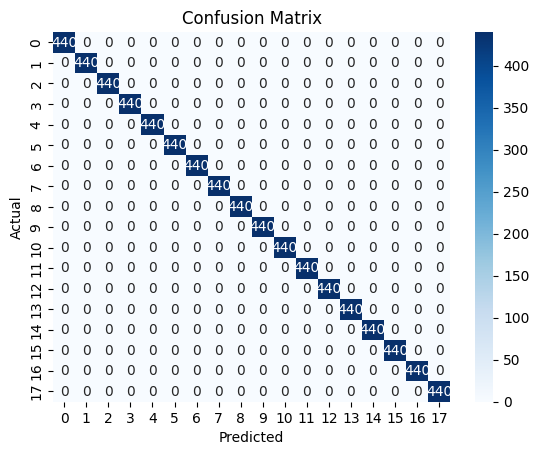

['rf_model_Classification_on_Generated_Features_joblib.pkl']

In [14]:
def evaluate_model(test_labels, pred_labels, pred_labels_proba):
    '''
    This function is use to model evaluation.
    
    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.
    
    Output: None
    '''
    # Evaluate the model
    print("\n" + "="*50)
    print("MODEL EVALUATION")
    print("="*50)

    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc
    
    # AUC-ROC
    roc_auc = roc_auc_score(test_labels, pred_labels_proba, multi_class='ovr') # .to_numpy().reshape(-1, 1)

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    print(f"ROC-AUC: {roc_auc*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    
# Evaluate Model
y_pred = rf_model.predict(X_train)
y_pred_proba = rf_model.predict_proba(X_train)

evaluate_model(y_train, y_pred, y_pred_proba)

# save model
joblib.dump(rf_model, 'rf_model_Classification_on_Generated_Features_joblib.pkl')
# loaded_model = joblib.load('model_joblib.pkl')


MODEL EVALUATION
Accuracy: 100.00 %
Log Loss: 0.00 %
ROC-AUC: 100.00 %
Cohen's Kappa Score: 100.00 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       110
           2       1.00      1.00      1.00       110
           3       1.00      1.00      1.00       110
           4       1.00      1.00      1.00       110
           5       1.00      1.00      1.00       110
           6       1.00      1.00      1.00       110
           7       1.00      1.00      1.00       110
           8       1.00      1.00      1.00       110
           9       1.00      1.00      1.00       110
          10       1.00      1.00      1.00       110
          11       1.00      1.00      1.00       110
          12       1.00      1.00      1.00       110
          13       1.00      1.00      1.00       110
          14       1.00      1.00      1.00       110
         

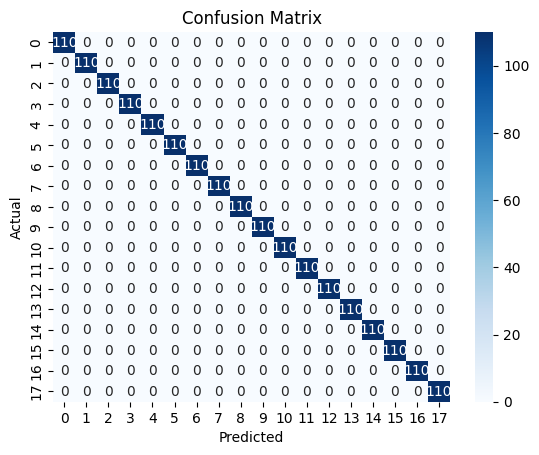

In [15]:
# Evaluate Model
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

evaluate_model(y_test, y_pred, y_pred_proba)

In [16]:
# rt_gen = RealTimeGenerator(
#     'infogan_conditional_model',
#     scaler,
#     label_encoder
# )

# class_name = 1 # <-----------

# samples = rt_gen.generate_variations(class_name, n_variations=1)
# # Add class name to each sample and save
# for i, sample in enumerate(samples):
#     all_rows_variations.append({
#         'class_name': class_name,
#         'sample_id': i,
#         **{f'feature_{j}': sample[j] for j in range(len(sample))}
#     })
    
# len(all_rows_variations)

rt_gen = RealTimeGenerator(
    'infogan_conditional_model',
    scaler,
    label_encoder
)

class_name = 1  # <-----------

samples = rt_gen.generate_variations(class_name, n_variations=1)
# print(len(samples))

# Since we only have one sample, we can directly create a single dictionary
if len(samples) > 0:  # Check if samples were generated
    single_sample = {
        'class_name': class_name,
        'sample_id': 0,
        **{f'feature_{j}': samples[0][j] for j in range(len(samples[0]))}
    }
    
    # If you still want to maintain a list (even with just one item)
    all_rows_variations = [single_sample]
    
    print(f"Generated 1 sample for class {class_name}")
    print(f"Features: {len(samples[0])} dimensions")
else:
    print(f"No samples generated for class {class_name}")
    all_rows_variations = []

len(all_rows_variations)  # This will now be 1 if generation was successful

 RealTimeGenerator ready!
Generated 1 sample for class 1
Features: 512 dimensions


1

In [17]:
# DataFrame 1: All variations (auto style)
df_variations = pd.DataFrame(all_rows_variations)
print(f" Variations DataFrame created: {df_variations.shape}")
df_variations.head()

 Variations DataFrame created: (1, 514)


,class_name,sample_id,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,1,0,2.930921,0.36169,2.521123,0.725262,1.633051,0.972503,0.546167,-0.879437,...,1.082204,1.006902,0.496516,1.660187,1.025454,0.751363,0.974716,0.166953,0.861914,-0.523329


# Start data test

In [41]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, cohen_kappa_score, log_loss
import joblib
import pickle



In [19]:
# Feature Extractor
def build_feature_extractor():
    base_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    return base_model

# def preprocess_image(image_path):
#     """
#     Preprocess a single image for prediction
#     """
#     # Load image
#     img = image.load_img(image_path, target_size=(224, 224))

#     # Convert to array
#     img_array = image.img_to_array(img)

#     # Add batch dimension (1, 224, 224, 3)
#     img_array = np.expand_dims(img_array, axis=0)

#     # Apply VGG16 preprocessing (same as training)
#     img_array = preprocess_input(img_array)

#     return img_array

# def predict_single_image(image_path, threshold=0.5):
#     """
#     Predict class for a single image

#     Args:
#         image_path: Path to input image
#         threshold: Probability threshold for multi-label classification

#     Returns:
#         Predicted class(es) and probabilities
#     """
#     # Preprocess
#     processed_img = preprocess_image(image_path)

#     # Extract features
#     features = feature_extractor.predict(processed_img, verbose=0)

#     # Get predictions from classifier
#     predictions = classifier.predict(features, verbose=0)

#     return predictions[0]  # Return probabilities for all classes
    
    
    
def predict_medical_image(image_path, feature_extractor, classifier, scaler, threshold=0.5):
    # Load and preprocess
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    # Extract features and predict
    features = feature_extractor.predict(img_array, verbose=0)
    features_scaled = scaler.transform(features)
    predictions = classifier.predict(features)[0]  # probabilities for each class
    
    
    return features, predictions

In [20]:
# Create the feature extractor
image_path = os.path.join('awa_data', 'train', 'bobcat', 'bobcat_10008.jpg')
feature_extractor = build_feature_extractor()
classifier = joblib.load('model_joblib.pkl')
scaler = joblib.load('scaler_joblib.pkl')
features, predictions = predict_medical_image(image_path, feature_extractor, classifier, scaler)


scaler = joblib.load('RealTimeGenerator_scaler_joblib.pkl')
label_encoder = joblib.load('RealTimeGenerator_label_encoder_joblib.pkl')
# Initialize real-time generator
rt_gen = RealTimeGenerator(
    'infogan_conditional_model',
    scaler,
    label_encoder
)
samples = rt_gen.generate_variations(predictions, n_variations=1, noise=features)


# Classification on Generated Features
rf_classification_model = joblib.load('rf_model_Classification_on_Generated_Features_joblib.pkl')
result = rf_classification_model.predict(samples)
result_proba = rf_classification_model.predict_proba(samples)

result, result_proba, lables_dict[result[0]]

 RealTimeGenerator ready!


(array([2], dtype=int64),
 array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.]]),
 'bobcat')

In [21]:
import pandas as pd
import numpy as np

from skimage.feature import graycomatrix, graycoprops

from sentence_transformers import SentenceTransformer, util
import torch
# 1. SciBert - (pritamdeka/S-Scibert-snli-multinli-stsb)
# 2. BioBERT- (emilyalsentzer/Bio_ClinicalBERT)
# 3. Transformer model (all-MiniLM-L6-v2)
# 4. RoBERTa (sentence-transformers/all-roberta-large-v1)

In [31]:
SentenceTransformer_model = SentenceTransformer('all-MiniLM-L6-v2', trust_remote_code=True)

seen_class_labels = ["bear", "blue_whale", "bobcat", "cow", "dolphin", "gorilla", 
                     "killer_whale", "lion", "monkey", "mouse", "ox", "rabbit", 
                     "rhinoceros", "siamese_cat", "skunk", "squirrel", "tiger", "walrus"]
seen_idx_to_class = {k: v for k, v in enumerate(seen_class_labels)}
seen_words = list(seen_idx_to_class.values())
seen_embeddings = SentenceTransformer_model.encode(seen_words, convert_to_tensor=True)
print(len(seen_embeddings))
print("="*60)

unseen_class_labels = ['chimpanzee', 'giant_panda', 'hippopotamus', 'humpback_whale', 'leopard', 
                       'persian_cat', 'pig', 'raccoon', 'rat', 'seal']
unseen_idx_to_class = {k: v for k, v in enumerate(unseen_class_labels)}
unseen_words = list(unseen_idx_to_class.values())
unseen_embeddings = SentenceTransformer_model.encode(unseen_words, convert_to_tensor=True)
print(len(unseen_embeddings))
print("="*60)

18
10


In [52]:
def get_top_similar_classes_df(predicted_class,
                               sentence_model,
                               class_embeddings,
                               class_labels,
                               k=5):
    """
    Get top k similar classes and return them as a tuple of lists
    """
    # Encode the predicted class
    unseen_query = sentence_model.encode(predicted_class,
                                         convert_to_tensor=True)

    # Calculate cosine similarities
    unseen_cosine_scores = util.cos_sim(unseen_query,
                                        class_embeddings)
    unseen_top_results = torch.topk(unseen_cosine_scores[0],
                                    k=k)

    # Extract top class names and probabilities
    top_class_names = []
    top_probabilities = []
    for score, idx in zip(unseen_top_results.values,
                          unseen_top_results.indices):
        top_class_names.append(class_labels[idx])
        top_probabilities.append(float(f"{score:.2f}"))

    return top_class_names, top_probabilities



# print(lables_dict[result[0]])

# print(get_top_similar_classes_df(lables_dict[result[0]],
#                             SentenceTransformer_model,
#                             seen_embeddings,
#                             seen_class_labels))

# print(get_top_similar_classes_df(lables_dict[result[0]],
#                             SentenceTransformer_model,
#                             unseen_embeddings,
#                             unseen_class_labels))

In [59]:
import glob

image_paths, image_names, act_lables, top_seen_labels, top_unseen_labels = [], [], [], [], []
pred_labels, act_vals, pred_vals = [], [], []


for i in glob.glob(os.path.join('awa_data', 'train', '*', '*')):
    image_path = i
    image_name = i.split('\\')[-1]
    act_lable = i.split('\\')[-2]
    
    
    feature_extractor = build_feature_extractor()
    classifier = joblib.load('model_joblib.pkl')
    scaler = joblib.load('scaler_joblib.pkl')
    features, predictions = predict_medical_image(image_path, feature_extractor, classifier, scaler)


    scaler = joblib.load('RealTimeGenerator_scaler_joblib.pkl')
    label_encoder = joblib.load('RealTimeGenerator_label_encoder_joblib.pkl')
    # Initialize real-time generator
    rt_gen = RealTimeGenerator(
        'infogan_conditional_model',
        scaler,
        label_encoder
    )
    samples = rt_gen.generate_variations(predictions, n_variations=1, noise=features)


    # Classification on Generated Features
    rf_classification_model = joblib.load('rf_model_Classification_on_Generated_Features_joblib.pkl')
    pred_label = rf_classification_model.predict(samples)[0]

    top_seen_label = get_top_similar_classes_df(lables_dict[pred_label],
                            SentenceTransformer_model,
                            seen_embeddings,
                            seen_class_labels)[0]
    
#     print(top_seen_label)
    
    top_unseen_label = get_top_similar_classes_df(lables_dict[pred_label],
                            SentenceTransformer_model,
                            unseen_embeddings,
                            unseen_class_labels)[0]
#     print(top_unseen_label)
    
    
    image_paths.append(image_path) 
    image_names.append(image_name) 
    act_lables.append(act_lable)
    pred_labels.append(lables_dict[pred_label])
    act_vals.append(class_dict[act_lable])
    pred_vals.append(pred_label)
    top_seen_labels.append(top_seen_label)  
    top_unseen_labels.append(top_unseen_label) 
    
#     break

 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


...

 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


In [64]:
seen_result_df = pd.DataFrame({
    'image_paths': image_paths,
    'image_names': image_names,
    'act_lables': act_lables,
    'pred_labels': pred_labels,
    'act_vals': act_vals,
    'pred_vals': pred_vals,
    'top_seen_labels': top_seen_labels,
    'top_unseen_labels': top_unseen_labels
})
seen_result_df.head()

,image_paths,image_names,act_lables,pred_labels,act_vals,pred_vals,top_seen_labels,top_unseen_labels
0,awa_data\train\bear\bear_10001 (1).jpg,bear_10001 (1).jpg,bear,bear,0,0,"[bear, walrus, rabbit, squirrel, cow]","[rat, pig, raccoon, leopard, humpback_whale]"
1,awa_data\train\bear\bear_10001 (10).jpg,bear_10001 (10).jpg,bear,tiger,0,16,"[tiger, lion, squirrel, gorilla, monkey]","[leopard, rat, pig, chimpanzee, persian_cat]"
2,awa_data\train\bear\bear_10001 (11).jpg,bear_10001 (11).jpg,bear,bear,0,0,"[bear, walrus, rabbit, squirrel, cow]","[rat, pig, raccoon, leopard, humpback_whale]"
3,awa_data\train\bear\bear_10001 (12).jpg,bear_10001 (12).jpg,bear,tiger,0,16,"[tiger, lion, squirrel, gorilla, monkey]","[leopard, rat, pig, chimpanzee, persian_cat]"
4,awa_data\train\bear\bear_10001 (13).jpg,bear_10001 (13).jpg,bear,killer_whale,0,6,"[killer_whale, blue_whale, dolphin, bear, cow]","[humpback_whale, giant_panda, pig, rat, seal]"


In [66]:
# Create new column
seen_result_df['seen_pred_vals'] = seen_result_df.apply(
    lambda row: row['act_vals'] if row['act_lables'] in row['top_seen_labels'] else row['pred_vals'],
    axis=1
)

# seen_result_df['seen_pred_vals'] = np.where(
#     seen_result_df.apply(lambda row: row['act_labels'] in row['top_seen_labels'], axis=1),
#     seen_result_df['act_vals'],
#     seen_result_df['pred_vals']
# )


seen_result_df.head()

,image_paths,image_names,act_lables,pred_labels,act_vals,pred_vals,top_seen_labels,top_unseen_labels,seen_pred_vals
0,awa_data\train\bear\bear_10001 (1).jpg,bear_10001 (1).jpg,bear,bear,0,0,"[bear, walrus, rabbit, squirrel, cow]","[rat, pig, raccoon, leopard, humpback_whale]",0
1,awa_data\train\bear\bear_10001 (10).jpg,bear_10001 (10).jpg,bear,tiger,0,16,"[tiger, lion, squirrel, gorilla, monkey]","[leopard, rat, pig, chimpanzee, persian_cat]",16
2,awa_data\train\bear\bear_10001 (11).jpg,bear_10001 (11).jpg,bear,bear,0,0,"[bear, walrus, rabbit, squirrel, cow]","[rat, pig, raccoon, leopard, humpback_whale]",0
3,awa_data\train\bear\bear_10001 (12).jpg,bear_10001 (12).jpg,bear,tiger,0,16,"[tiger, lion, squirrel, gorilla, monkey]","[leopard, rat, pig, chimpanzee, persian_cat]",16
4,awa_data\train\bear\bear_10001 (13).jpg,bear_10001 (13).jpg,bear,killer_whale,0,6,"[killer_whale, blue_whale, dolphin, bear, cow]","[humpback_whale, giant_panda, pig, rat, seal]",0


In [67]:
seen_result_df.tail()

,image_paths,image_names,act_lables,pred_labels,act_vals,pred_vals,top_seen_labels,top_unseen_labels,seen_pred_vals
715,awa_data\train\walrus\walrus_10036.jpg,walrus_10036.jpg,walrus,dolphin,17,4,"[dolphin, blue_whale, killer_whale, cow, lion]","[humpback_whale, leopard, rat, raccoon, seal]",4
716,awa_data\train\walrus\walrus_10037.jpg,walrus_10037.jpg,walrus,tiger,17,16,"[tiger, lion, squirrel, gorilla, monkey]","[leopard, rat, pig, chimpanzee, persian_cat]",16
717,awa_data\train\walrus\walrus_10038.jpg,walrus_10038.jpg,walrus,ox,17,10,"[ox, monkey, cow, lion, tiger]","[leopard, pig, rat, humpback_whale, persian_cat]",10
718,awa_data\train\walrus\walrus_10039.jpg,walrus_10039.jpg,walrus,tiger,17,16,"[tiger, lion, squirrel, gorilla, monkey]","[leopard, rat, pig, chimpanzee, persian_cat]",16
719,awa_data\train\walrus\walrus_10040.jpg,walrus_10040.jpg,walrus,tiger,17,16,"[tiger, lion, squirrel, gorilla, monkey]","[leopard, rat, pig, chimpanzee, persian_cat]",16


In [68]:
seen_result_df.to_csv('seen_result_df.csv', index=False)


MODEL EVALUATION
Accuracy: 49.58 %
Log Loss: 50.42 %
Cohen's Kappa Score: 46.62 %

classification_report:
              precision    recall  f1-score   support

           0       0.77      0.50      0.61        40
           1       1.00      0.93      0.96        40
           2       0.17      0.35      0.23        40
           3       0.84      0.93      0.88        40
           4       0.96      0.57      0.72        40
           5       0.96      0.57      0.72        40
           6       0.73      0.40      0.52        40
           7       0.97      0.97      0.97        40
           8       1.00      0.88      0.93        40
           9       0.00      0.00      0.00        40
          10       0.24      0.85      0.37        40
          11       1.00      0.47      0.64        40
          12       0.00      0.00      0.00        40
          13       0.73      0.20      0.31        40
          14       0.00      0.00      0.00        40
          15       1.00     

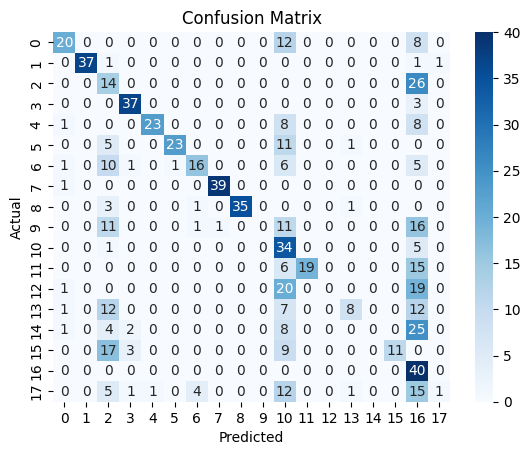

In [78]:
def evaluate_model_final(test_labels, pred_labels):
    '''
    This function is use to model evaluation.
    
    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.
    
    Output: None
    '''
    # Evaluate the model
    print("\n" + "="*50)
    print("MODEL EVALUATION")
    print("="*50)

    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc
    
    # AUC-ROC
#     roc_auc = roc_auc_score(test_labels, pred_labels_proba, multi_class='ovr') # .to_numpy().reshape(-1, 1)

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
#     print(f"ROC-AUC: {roc_auc*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    
# Evaluate Model
y_train = seen_result_df['act_vals'].values 
y_pred = seen_result_df['seen_pred_vals'].values 

evaluate_model_final(y_train, y_pred)


In [79]:
unseen_class_labels = sorted([path.split('\\')[-1] for path in glob.glob(os.path.join('awa_data', 'unseen', '*'))])
unseen_lables_dict = {k:v for k, v in enumerate(unseen_class_labels) }
unseen_class_dict = {v: k for k, v in unseen_lables_dict.items()}
print(unseen_class_labels)
print(unseen_lables_dict)
print(unseen_class_dict)

['chimpanzee', 'giant_panda', 'hippopotamus', 'humpback_whale', 'leopard', 'persian_cat', 'pig', 'raccoon', 'rat', 'seal']
{0: 'chimpanzee', 1: 'giant_panda', 2: 'hippopotamus', 3: 'humpback_whale', 4: 'leopard', 5: 'persian_cat', 6: 'pig', 7: 'raccoon', 8: 'rat', 9: 'seal'}
{'chimpanzee': 0, 'giant_panda': 1, 'hippopotamus': 2, 'humpback_whale': 3, 'leopard': 4, 'persian_cat': 5, 'pig': 6, 'raccoon': 7, 'rat': 8, 'seal': 9}


In [81]:
import glob

image_paths, image_names, act_lables, top_seen_labels, top_unseen_labels = [], [], [], [], []
pred_labels, act_vals, pred_vals = [], [], []


for i in glob.glob(os.path.join('awa_data', 'unseen', '*', '*')):
    image_path = i
    image_name = i.split('\\')[-1]
    act_lable = i.split('\\')[-2]
    
    
    feature_extractor = build_feature_extractor()
    classifier = joblib.load('model_joblib.pkl')
    scaler = joblib.load('scaler_joblib.pkl')
    features, predictions = predict_medical_image(image_path, feature_extractor, classifier, scaler)


    scaler = joblib.load('RealTimeGenerator_scaler_joblib.pkl')
    label_encoder = joblib.load('RealTimeGenerator_label_encoder_joblib.pkl')
    # Initialize real-time generator
    rt_gen = RealTimeGenerator(
        'infogan_conditional_model',
        scaler,
        label_encoder
    )
    samples = rt_gen.generate_variations(predictions, n_variations=1, noise=features)


    # Classification on Generated Features
    rf_classification_model = joblib.load('rf_model_Classification_on_Generated_Features_joblib.pkl')
    pred_label = rf_classification_model.predict(samples)[0]

    top_seen_label = get_top_similar_classes_df(lables_dict[pred_label],
                            SentenceTransformer_model,
                            seen_embeddings,
                            seen_class_labels)[0]
    
#     print(top_seen_label)
    
    top_unseen_label = get_top_similar_classes_df(lables_dict[pred_label],
                            SentenceTransformer_model,
                            unseen_embeddings,
                            unseen_class_labels)[0]
#     print(top_unseen_label)
    
    
    image_paths.append(image_path) 
    image_names.append(image_name) 
    act_lables.append(act_lable)
    pred_labels.append(lables_dict[pred_label])
    act_vals.append(unseen_class_dict[act_lable])
    pred_vals.append(pred_label)
    top_seen_labels.append(top_seen_label)  
    top_unseen_labels.append(top_unseen_label) 
    
#     break

 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!
 RealTimeGenerator ready!


In [82]:
unseen_result_df = pd.DataFrame({
    'image_paths': image_paths,
    'image_names': image_names,
    'act_lables': act_lables,
    'pred_labels': pred_labels,
    'act_vals': act_vals,
    'pred_vals': pred_vals,
    'top_seen_labels': top_seen_labels,
    'top_unseen_labels': top_unseen_labels
})
unseen_result_df.head()

,image_paths,image_names,act_lables,pred_labels,act_vals,pred_vals,top_seen_labels,top_unseen_labels
0,awa_data\unseen\chimpanzee\chimpanzee_10001.jpg,chimpanzee_10001.jpg,chimpanzee,ox,0,10,"[ox, monkey, cow, lion, tiger]","[leopard, pig, rat, humpback_whale, persian_cat]"
1,awa_data\unseen\chimpanzee\chimpanzee_10002.jpg,chimpanzee_10002.jpg,chimpanzee,tiger,0,16,"[tiger, lion, squirrel, gorilla, monkey]","[leopard, rat, pig, chimpanzee, persian_cat]"
2,awa_data\unseen\chimpanzee\chimpanzee_10003.jpg,chimpanzee_10003.jpg,chimpanzee,ox,0,10,"[ox, monkey, cow, lion, tiger]","[leopard, pig, rat, humpback_whale, persian_cat]"
3,awa_data\unseen\chimpanzee\chimpanzee_10004.jpg,chimpanzee_10004.jpg,chimpanzee,ox,0,10,"[ox, monkey, cow, lion, tiger]","[leopard, pig, rat, humpback_whale, persian_cat]"
4,awa_data\unseen\chimpanzee\chimpanzee_10005.jpg,chimpanzee_10005.jpg,chimpanzee,ox,0,10,"[ox, monkey, cow, lion, tiger]","[leopard, pig, rat, humpback_whale, persian_cat]"


In [83]:
# Create new column
unseen_result_df['unseen_pred_vals'] = unseen_result_df.apply(
    lambda row: row['act_vals'] if row['act_lables'] in row['top_unseen_labels'] else row['pred_vals'],
    axis=1
)

# seen_result_df['seen_pred_vals'] = np.where(
#     seen_result_df.apply(lambda row: row['act_labels'] in row['top_seen_labels'], axis=1),
#     seen_result_df['act_vals'],
#     seen_result_df['pred_vals']
# )


unseen_result_df.head()

,image_paths,image_names,act_lables,pred_labels,act_vals,pred_vals,top_seen_labels,top_unseen_labels,unseen_pred_vals
0,awa_data\unseen\chimpanzee\chimpanzee_10001.jpg,chimpanzee_10001.jpg,chimpanzee,ox,0,10,"[ox, monkey, cow, lion, tiger]","[leopard, pig, rat, humpback_whale, persian_cat]",10
1,awa_data\unseen\chimpanzee\chimpanzee_10002.jpg,chimpanzee_10002.jpg,chimpanzee,tiger,0,16,"[tiger, lion, squirrel, gorilla, monkey]","[leopard, rat, pig, chimpanzee, persian_cat]",0
2,awa_data\unseen\chimpanzee\chimpanzee_10003.jpg,chimpanzee_10003.jpg,chimpanzee,ox,0,10,"[ox, monkey, cow, lion, tiger]","[leopard, pig, rat, humpback_whale, persian_cat]",10
3,awa_data\unseen\chimpanzee\chimpanzee_10004.jpg,chimpanzee_10004.jpg,chimpanzee,ox,0,10,"[ox, monkey, cow, lion, tiger]","[leopard, pig, rat, humpback_whale, persian_cat]",10
4,awa_data\unseen\chimpanzee\chimpanzee_10005.jpg,chimpanzee_10005.jpg,chimpanzee,ox,0,10,"[ox, monkey, cow, lion, tiger]","[leopard, pig, rat, humpback_whale, persian_cat]",10


In [84]:
unseen_result_df.to_csv('unseen_result_df.csv', index=False)


MODEL EVALUATION
Accuracy: 51.00 %
Log Loss: 49.00 %
Cohen's Kappa Score: 47.71 %

classification_report:
              precision    recall  f1-score   support

           0       0.75      0.30      0.43        10
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00        10
           3       0.91      1.00      0.95        10
           4       1.00      1.00      1.00        10
           5       1.00      0.70      0.82        10
           6       0.91      1.00      0.95        10
           7       0.00      0.00      0.00        10
           8       1.00      1.00      1.00        10
           9       1.00      0.10      0.18        10
          10       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0
          16       0.00      0.00      0.00         0

    accuracy                           0.51       100
   macro avg       0.51      0.39      0.41       100
weighted avg       0.66    

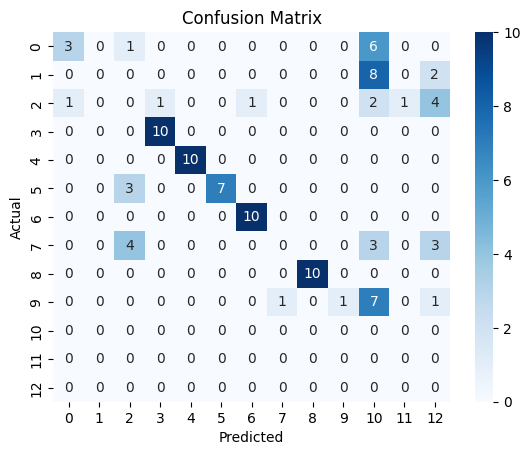

In [86]:
# Evaluate Model
y_train = unseen_result_df['act_vals'].values 
y_pred = unseen_result_df['unseen_pred_vals'].values 

evaluate_model_final(y_train, y_pred)

In [ ]:
# # https://www.youtube.com/watch?v=t9kWvUb4KEQ
# import requests

# api_key = '6a47d8edfeb0c250371d5bd429484af8'
# base_url = 'https://api.openweathermap.org/data/2.5/weather'
# city = 'mumbai'

# request_url = f"{base_url}?q={city}&appid={api_key}&units=metric"
# response = requests.get(request_url)
# response

# if response.status_code == 200:
#     data = response.json()
    
# print(data)
# # weather
# # temp
# # temp_min
# # temp_max
# # feels_like
# # humidity
# # visibility
# # wind_speed